# Prompt Eval Workflow

> **Best practice:** Run the prompt through an evaluation pipeline to score it objectively, then iterate it

Typical prompt eval workflow:

```mermaid
graph TD
    A[Draft Prompt] --> B[Create Eval Dataset]
    B --> C
    C[Feed through Claude] --> D[Feed through Grader that returns a score]
    D --> E[Change Prompt]
    E --> A

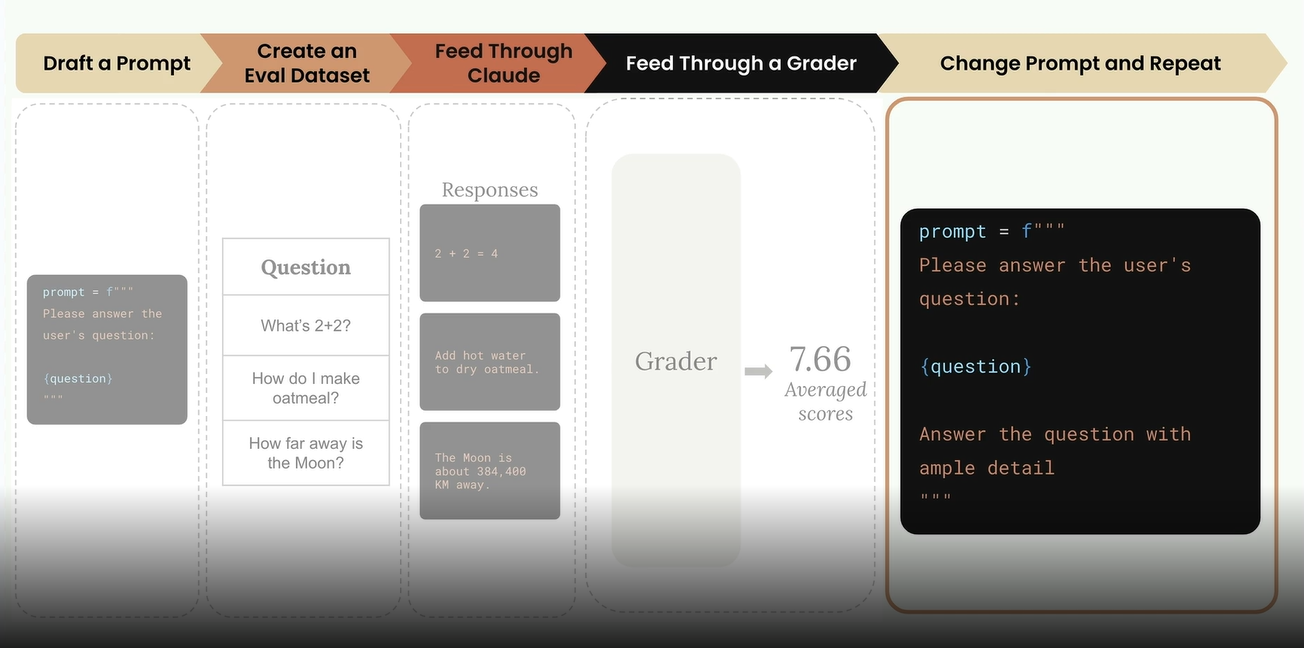

### Task

Let's code a initial version of a prompt that will assist users in writing python code, json config or regex focused on aws specific use cases

* Input: User will request code for a specific task
* Output: Python, JSON, or regex without any explanation

### Init steps and helper functions

In [2]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [3]:
# Helper functions
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)


def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[]):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

In [12]:
import json

# Usa claude para generar el dataset
def generate_dataset():
    prompt = """
Generate a evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts
that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects,
each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
    {
        "task": "Description of task",
    },
    ...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a regular expression.
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""
    messages = []
    add_user_message(messages,prompt)
    add_assistant_message(messages,"```json")
    text = chat(messages,stop_sequences=["```"])
    return json.loads(text)

### Generate eval dataset with Claude and save it in a json file

In [15]:
dataset = generate_dataset()
dataset

with open("dataset.json","w") as f:
    json.dump(dataset,f,indent=2)

### Running the eval with each test case

This is how a eval pipeline is done (except from Grading, which is the tricky part)

In [17]:
def run_prompt(test_case):
    """Merges the prmpt and test case input, then returns the result"""
    prompt = f"""
    Please solve the following task:

    {test_case['task']}
    """
    messages = []
    add_user_message(messages,prompt)
    output = chat(messages)
    return output

def run_test_case(test_case):
    """Calls run_prompt, then grades the result"""
    output = run_prompt(test_case)

    # TODO- Grading
    score = 10

    return {
        "output":output,
        "test_case":test_case,
        "score":score
    }

def run_eval(dataset):
    """Loads the dataset and calls run_test_case with each case"""
    results = []
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)

    return results

In [18]:
# Even with Haiku, it took around 30+ seconds
with open("dataset.json","r") as f:
    dataset = json.load(f)

results = run_eval(dataset)

In [20]:
print(json.dumps(results,indent=2))

[
  {
    "output": "# AWS S3 Bucket Name Validator\n\nHere's a comprehensive solution with validation function and test cases:\n\n```python\nimport re\n\ndef validate_s3_bucket_name(bucket_name: str) -> tuple[bool, str]:\n    \"\"\"\n    Validates an AWS S3 bucket name according to AWS naming rules.\n    \n    Rules:\n    - Length: 3-63 characters\n    - Characters: lowercase letters (a-z), numbers (0-9), and hyphens (-)\n    - Must start with a lowercase letter or number\n    - Must end with a lowercase letter or number\n    - Cannot contain consecutive hyphens\n    - Cannot be formatted as an IP address (e.g., 192.168.1.1)\n    \n    Args:\n        bucket_name: The bucket name to validate\n        \n    Returns:\n        tuple: (is_valid: bool, message: str)\n    \"\"\"\n    \n    # Check if input is a string\n    if not isinstance(bucket_name, str):\n        return False, \"Bucket name must be a string\"\n    \n    # Check length\n    if len(bucket_name) < 3:\n        return False,

### Grading ⭐

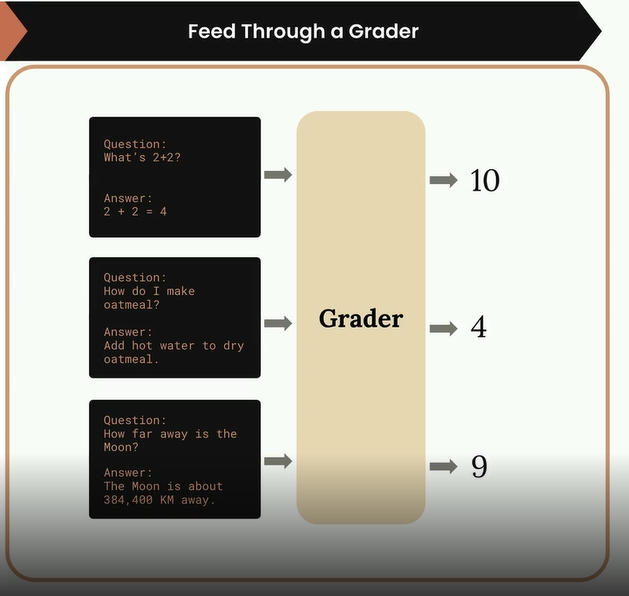

Till now we have hardoded the grading (`score=10`) to quickly see what is it, but there are different techniques for grading

* Model based grading
* Code based grading
* Human based grading

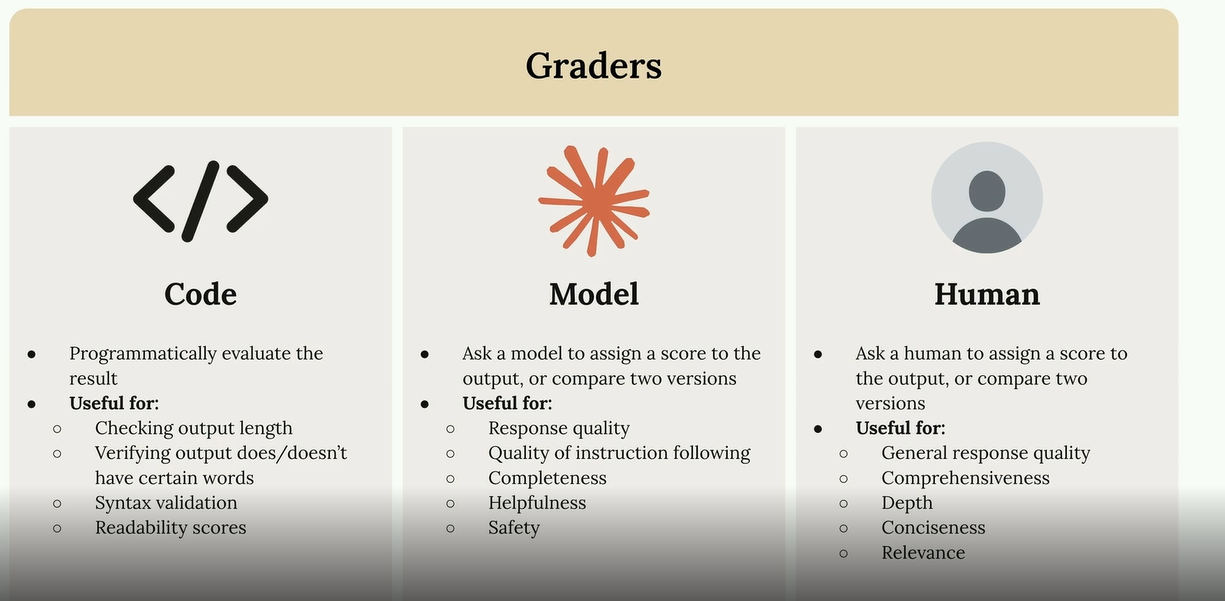

For this exercise objective, we could have these **evaluation criterias**, and measure them with the following grading techniques

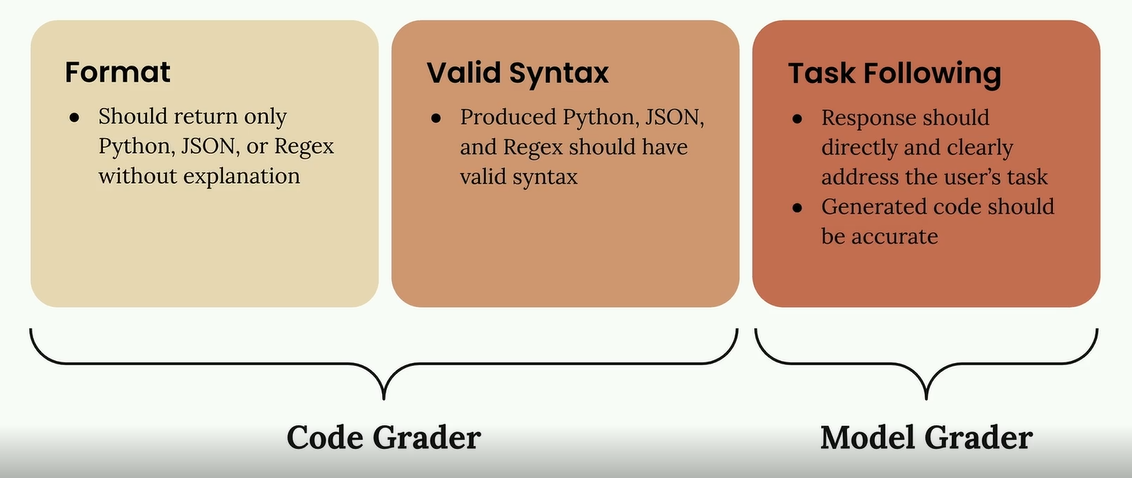

#### ⭐Model Grader

* **It is critical to request strenghts/weaknesses and reasoning to the model along with the score** so that the score varies (if not, the score may end up being around 6/10).
* **It uses (again) the prefilled message and stop prompt to capture only the json output**

In [36]:
# Function to grade a test case + output using a model (I've copied and pasted this from their notebook, as it is quite long prompt)
# 🚨🚨🚨THIS ONE FAILS BECAUSE OF JSON ESCAPE CHARACTERS... 🚨🚨🚨

def grade_by_model(test_case, output):
    eval_prompt = f"""
You are an expert AWS code reviewer. Your task is to evaluate the following AI-generated solution.

Original Task:
<task>
{test_case["task"]}
</task>

Solution to Evaluate:
<solution>
{output}
</solution>

Output Format
Provide your evaluation as a structured JSON object with the following fields, in this specific order:
- "strengths": An array of 1-3 key strengths
- "weaknesses": An array of 1-3 key areas for improvement
- "reasoning": A concise explanation of your overall assessment
- "score": A number between 1-10

Respond with JSON. Keep your response concise and direct.
Example response shape:
{{
    "strengths": string[],
    "weaknesses": string[],
    "reasoning": string,
    "score": number
}}
    """

    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, "```json")
    eval_text = chat(messages, stop_sequences=["```"])
    return json.loads(eval_text)

In [37]:
# ⭐ USE THIS ONE: CORRECTLY ESCAPES CHARACTERS (MORE RELIABLE)

def grade_by_model(test_case, output):
    eval_prompt = f"""
You are an expert AWS code reviewer. Your task is to evaluate the following AI-generated solution.

Original Task:
<task>
{test_case["task"]}
</task>

Solution to Evaluate:
<solution>
{output}
</solution>

Output Format
Provide your evaluation as a structured JSON object with the following fields, in this specific order:
- "strengths": An array of 1-3 key strengths
- "weaknesses": An array of 1-3 key areas for improvement
- "reasoning": A concise explanation of your overall assessment
- "score": A number between 1-10

CRITICAL JSON RULES: 
1. You must return strictly valid JSON. 
2. If your evaluation includes regular expressions, file paths, or ANY backslashes, you MUST double-escape them. 
3. For example, write `\\\\d` instead of `\\d`, and `\\\\.` instead of `\\.`.

Respond with JSON. Keep your response concise and direct.
Example response shape:
{{
    "strengths": string[],
    "weaknesses": string[],
    "reasoning": string,
    "score": number
}}
    """

    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, "```json")
    
    eval_text = chat(messages, stop_sequences=["```"])
    
    # We can drop the regex sanitization entirely now and trust the prompt
    return json.loads(eval_text, strict=False)

In [38]:
def run_test_case(test_case):
    """Calls run_prompt, then grades the result"""
    output = run_prompt(test_case)

    # Model grading
    model_grade = grade_by_model(test_case,output)
    score = model_grade["score"]
    reasoning = model_grade["reasoning"]

    return {
        "output":output,
        "test_case":test_case,
        "score":score,
        "reasoning":reasoning
    }

In [39]:
# Let's run this again this time with Model Grading
with open("dataset.json","r") as f:
    dataset = json.load(f)

results = run_eval(dataset)
print(json.dumps(results,indent=2))

[
  {
    "output": "# AWS S3 Bucket Name Validator\n\n```python\nimport re\n\ndef validate_s3_bucket_name(bucket_name):\n    \"\"\"\n    Validates an AWS S3 bucket name according to AWS naming rules.\n    \n    AWS S3 bucket naming rules:\n    - Length: 3-63 characters\n    - Allowed characters: lowercase letters (a-z), numbers (0-9), and hyphens (-)\n    - Must start with a lowercase letter or number\n    - Must end with a lowercase letter or number\n    - Cannot contain consecutive hyphens\n    - Cannot be formatted as an IP address (e.g., 192.168.1.1)\n    \n    Args:\n        bucket_name (str): The S3 bucket name to validate\n        \n    Returns:\n        tuple: (is_valid: bool, message: str)\n            - is_valid: True if bucket name is valid, False otherwise\n            - message: Description of the validation result\n    \"\"\"\n    \n    # Check if input is a string\n    if not isinstance(bucket_name, str):\n        return False, \"Bucket name must be a string\"\n    \n  

##### Get the average score

In [41]:
from statistics import mean
def run_eval(dataset):
    """Loads the dataset and calls run_test_case with each case"""
    results = []
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)

    average_score = mean([result["score"] for result in results])
    print(f"Average score: {average_score}")

    return results

In [42]:
# Let's run this again and see the average score
with open("dataset.json","r") as f:
    dataset = json.load(f)

results = run_eval(dataset)

Average score: 6.333333333333333


#### ⭐Code Grader

* Ensure that we have valid syntax and ensure that returns only python, json or regex. How? **Look at this:**

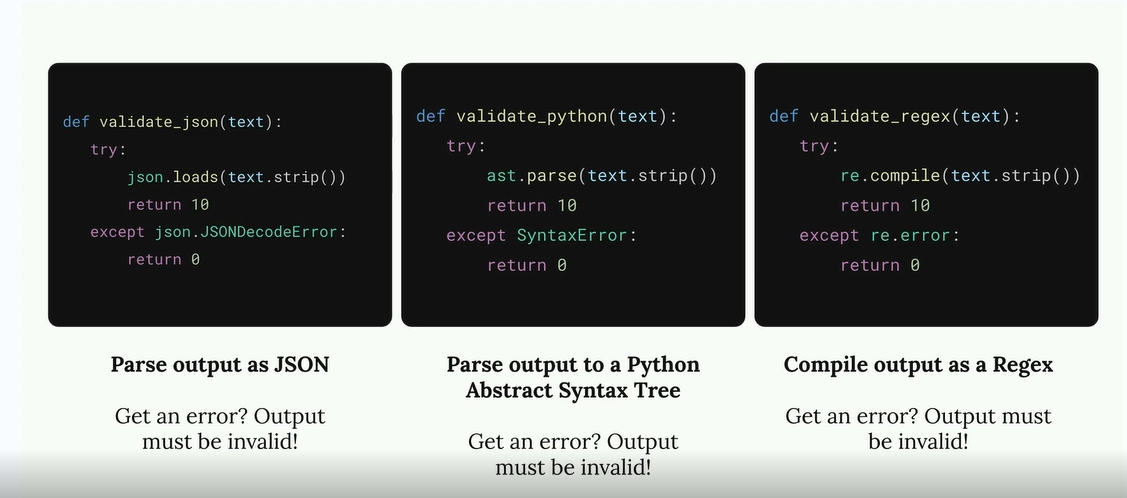

**Steps**

1. Add functions to validate JSON/Python/Regex
2. Make sure our dataset test cases indicate the type of generated content (JSON, Python, or Regex) by adding `format` key to our eval (look cell below)
3. Update our draft prompt to make it clear we only want the relevant JSON/Python/Regex
4. Final score: Merge the scores from the model grader and the code grader

Step 2 visual explanation:

We will first update our prompt so that the `format` key is included in each task (we are not editing the json file but the json variable). Eval dataset (in memory) will look like this:

```json
[
  {
    "task": "Write a Python function that validates an AWS S3 bucket name according to AWS naming rules (3-63 characters, lowercase letters, numbers, and hyphens only, must start and end with a letter or number)",
	"format":"python"
  },
  {
    "task": "Create a JSON CloudFormation template snippet that defines an AWS IAM role with a trust relationship allowing EC2 instances to assume it",
	"format":"json"
  },
  {
    "task": "Write a regular expression that matches valid AWS ARN (Amazon Resource Name) formats for any AWS service",
	"format":"regex"
  }
]

##### Step1: Functions to validate the output structure (either json, python or regex) ⭐⭐

In [44]:
# Functions to validate the output structure
import re 
import ast


def validate_json(text):
    try:
        json.loads(text.strip())
        return 10
    except json.JSONDecodeError:
        return 0


def validate_python(text):
    try:
        ast.parse(text.strip())
        return 10
    except SyntaxError:
        return 0


def validate_regex(text):
    try:
        re.compile(text.strip())
        return 10
    except re.error:
        return 0


def grade_syntax(response, test_case):
    format = test_case["format"] # 👁️
    if format == "json":
        return validate_json(response)
    elif format == "python":
        return validate_python(response)
    else:
        return validate_regex(response)

In [ ]:
def run_test_case(test_case):
    """Calls run_prompt, then grades the result"""
    output = run_prompt(test_case)

    # Model grading
    model_grade = grade_by_model(test_case,output)
    score = model_grade["score"]
    reasoning = model_grade["reasoning"]

    return {
        "output":output,
        "test_case":test_case,
        "score":score,
        "reasoning":reasoning
    }

##### Step 2: Make sure our dataset test cases indicate the type of generated content (JSON, Python, or Regex) by adding format key to our eval (look cell below)⭐⭐

In [45]:
import json

# Usa claude para generar el dataset
def generate_dataset():
    prompt = """
Generate a evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts
that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects,
each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
    {
        "task": "Description of task",
        "format": "json" or "python" or "regex"
    },
    ...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a regular expression.
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""
    messages = []
    add_user_message(messages,prompt)
    add_assistant_message(messages,"```json")
    text = chat(messages,stop_sequences=["```"])
    return json.loads(text)

In [46]:
# We generate the dataset again, this time with the "format" key in addition to the task key
dataset = generate_dataset()
dataset

with open("dataset.json","w") as f:
    json.dump(dataset,f,indent=2)

##### Step 3: Update our draft prompt to make it clear we only want the relevant JSON/Python/Regex⭐⭐

In [57]:
def run_prompt(test_case):
    """Merges the prmpt and test case input, then returns the result"""
    prompt = f"""
    Please solve the following task:

    {test_case['task']}

    * Respond only with Python, JSON, or plain Regex
    * Do not add any comments or commentary or explanation
    """
    messages = []
    add_user_message(messages,prompt)
    add_assistant_message(messages,"```code") # ✍️We write generic ```code
    output = chat(messages,stop_sequences=["```"])
    return output

##### Step 4: Final score: Merge the scores from the model grader and the code grader⭐⭐

In [58]:
def run_test_case(test_case):
    """Calls run_prompt, then grades the result"""
    output = run_prompt(test_case)

    # Model grading score
    model_grade = grade_by_model(test_case,output)
    model_score = model_grade["score"]
    print(f"Model score: {model_score}")
    reasoning = model_grade["reasoning"]

    # Syntax score: Either 10 or 0
    syntax_score = grade_syntax(output,test_case)
    print(f"Syntax score: {syntax_score}")

    # Merge syntax and model score

    score = (model_score + syntax_score)/2

    test_case_output = {
        "output":output,
        "test_case":test_case,
        "score":score,
        "reasoning":reasoning
    }
    print(test_case_output)
    return test_case_output

In [63]:
from statistics import mean
def run_eval(dataset):
    """Loads the dataset and calls run_test_case with each case"""
    results = []
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)

    average_score = mean([result["score"] for result in results])
    print(f"⭐⭐Average score for all tasks: {average_score} out of 10")

    return results

In [64]:
with open("dataset.json","r") as f:
    dataset = json.load(f)

results = run_eval(dataset)

Model score: 7
Syntax score: 10
{'output': "\nimport re\n\ndef parse_s3_bucket_name(s3_uri):\n    match = re.match(r's3://([a-z0-9.-]+)(?:/|$)', s3_uri)\n    if match:\n        return match.group(1)\n    return None\n\n# Test cases\nprint(parse_s3_bucket_name('s3://my-bucket-name/path/to/file.txt'))  # my-bucket-name\nprint(parse_s3_bucket_name('s3://another.bucket/'))  # another.bucket\nprint(parse_s3_bucket_name('s3://bucket-123'))  # bucket-123\n", 'test_case': {'task': "Parse an AWS S3 bucket name from a full S3 URI (e.g., 's3://my-bucket-name/path/to/file.txt') and extract just the bucket name", 'format': 'regex'}, 'score': 8.5, 'reasoning': "The solution effectively solves the core task with a clean regex approach and works correctly for typical S3 URI formats. However, it has modest robustness gaps: it lacks defensive input validation and doesn't fully account for uppercase characters that might appear in URIs. Additionally, it extracts the bucket name without validating AWS S3 